In [11]:
# -------------------------------
# Import des librairies
# -------------------------------
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Input, Model   
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [12]:
# -------------------------------
# Chargement et préparation des données
# -------------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Redimensionnement : (28x28) → (28x28x1)
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Encodage one-hot des labels (0–9)
display (y_train[0:5])
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

display (y_train[0:5])

array([5, 0, 4, 1, 9], dtype=uint8)

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

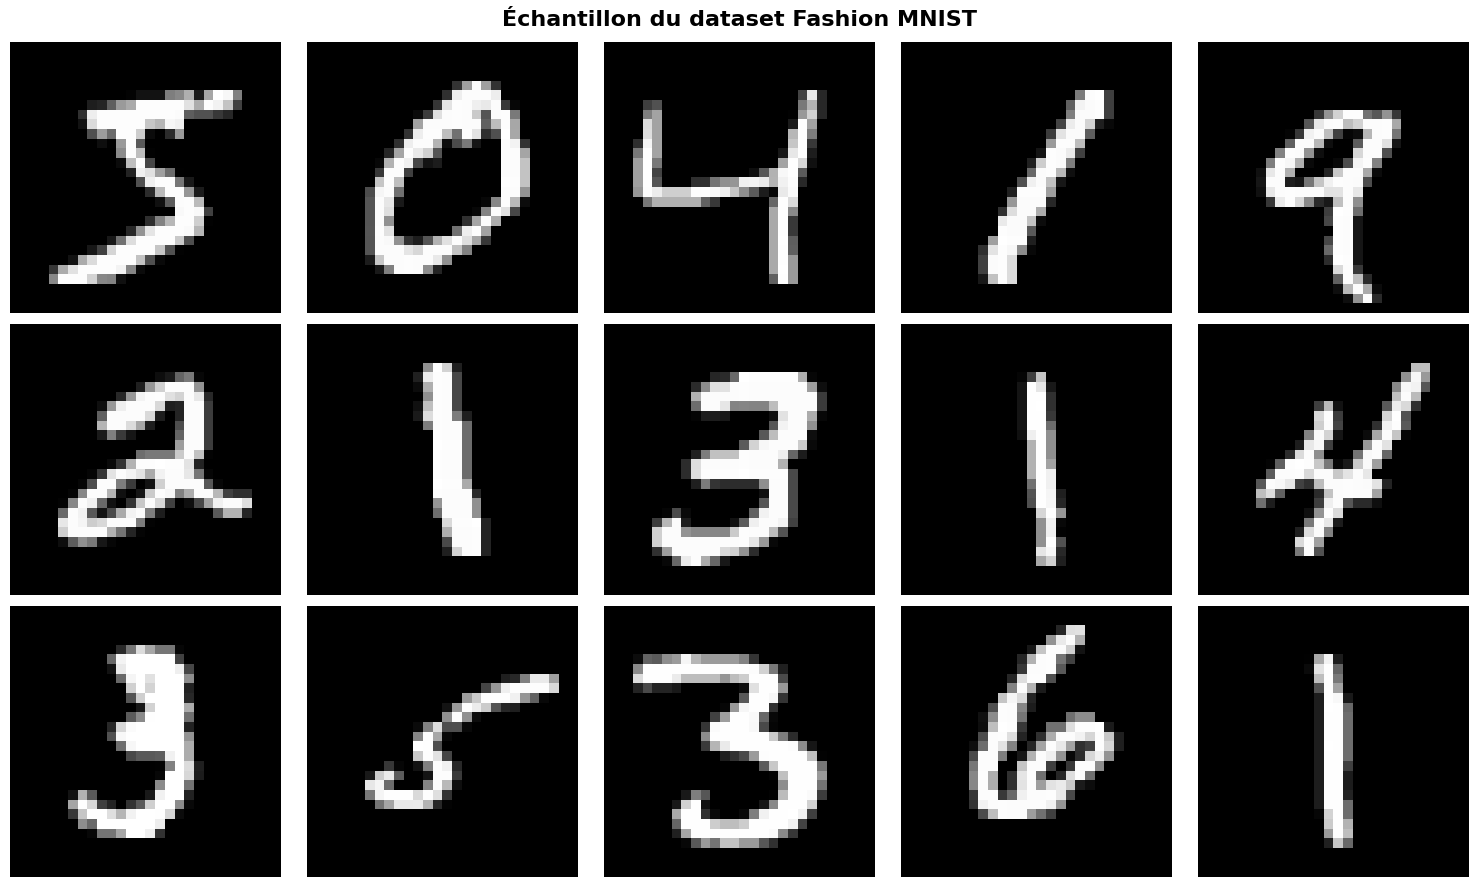

In [13]:
# Visualisation d'un échantillon d'images
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Échantillon du dataset Fashion MNIST', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    #ax.set_title(f'{class_names[y_train[i]]}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [14]:
# -------------------------------
# Création du modèle CNN
# -------------------------------
model = Sequential([
    # Couches convolutionnelles = extraction de motifs
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)), 
    MaxPooling2D((2, 2)),  # Réduction de dimension

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),  # Aplatit les cartes de caractéristiques
    Dense(64, activation='relu'),  # Couches fully connected
    Dense(10, activation='softmax')  # Sortie à 10 classes
])

def create_model():
    x = Sequential()
    x.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    x.add(MaxPooling2D((2, 2)))
    x.add(Conv2D(64, (3, 3), activation='relu'))
    x.add(MaxPooling2D((2, 2)))
    x.add(Flatten())
    x.add(Dense(64, activation='relu'))
    x.add(Dense(10, activation='softmax'))
    return x


# Fonction de création du modèle CNN avec l'API fonctionnelle
def create_model_functionnal():
    x = Input(shape=(28, 28, 1))
    x1 = Conv2D(32, (3, 3), activation='relu')(x)
    x2 = MaxPooling2D((2, 2))(x1)
    x3 = Conv2D(64, (3, 3), activation='relu')(x2)
    x4 = MaxPooling2D((2, 2))(x3)
    x5 = Flatten()(x4)
    x6 = Dense(64, activation='relu')(x5)
    output = Dense(10, activation='softmax')(x6)
    return Model(inputs=x, outputs=output)

/Users/jika/Desktop/ENSEIGMEMENT/Machine Learing/ALYRA - IA/ai-dev-teaching-hub/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model = create_model_functionnal()
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Explication des Couches :

# - Input : Définit la forme d'entrée (28x28x1 pour les images MNIST).
#   en sortie de la couche d'entrée, on a une image de 28x28 pixels avec 1 canal (niveaux de gris).

# - Conv2D : Applique des filtres pour extraire des motifs locaux (ex: bords, textures), avec 32 et 64 filtres respectivement et une taille de noyau de 3x3.

# - MaxPooling2D : Réduit la dimension spatiale (ex: 26x26 → 13x13) pour extraire les caractéristiques les plus importantes et réduire le nombre de paramètres.

#   En sortie de la première couche Conv2D, on a 32 cartes de caractéristiques de taille 26x26 (28-3+1).
#   après le MaxPooling2D, on a 32 cartes de caractéristiques de taille 13x13 (26/2).
#   après la deuxième couche Conv2D, on a 64 cartes de caractéristiques de taille 11x11 (13-3+1).
#   après le deuxième MaxPooling2D, on a 64 cartes de caractéristiques de taille 5x5 (11/2).

# - Flatten : Aplatit les cartes de caractéristiques en un vecteur 1D pour les couches fully connected.
#   en sortie du Flatten, on a un vecteur de 1600 éléments (64 cartes de caractéristiques x 5x5 pixels chacune).

# - Dense : Couches fully connected pour apprendre des combinaisons non linéaires de caractéristiques. 
# La dernière couche a 10 neurones avec activation softmax pour la classification multi-classes (0-9).


In [ ]:
# -------------------------------
# Compilation
# -------------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [18]:
# -------------------------------
# Entraînement
# -------------------------------
model.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.1, verbose=1)


Epoch 1/3


2026-06-30 19:37:10.895145: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9358 - loss: 0.2087 - val_accuracy: 0.9783 - val_loss: 0.0706
Epoch 2/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9766 - loss: 0.0778 - val_accuracy: 0.9860 - val_loss: 0.0501
Epoch 3/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9789 - loss: 0.0779 - val_accuracy: 0.9833 - val_loss: 0.0749


In [19]:
# -------------------------------
# Évaluation
# -------------------------------
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Précision sur MNIST : {test_acc:.2f}")


Précision sur MNIST : 0.98


In [25]:
y_test[0:5]

array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

In [11]:
# sauvegarde du modèle
model.save('Deep-Learning/models/mnist_simple_cnn_model.keras')